In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/GlobalWeatherRepository.csv")

df['last_updated'] = pd.to_datetime(df['last_updated'])

# Forecasting Models

This notebook focuses on building and evaluating forecasting models for predicting temperature trends using weather and environmental features.

## Feature Selection and Target Definition

Temperature in Celsius was selected as the prediction target. Highly redundant features such as Fahrenheit-based temperature variables were excluded to reduce duplication and improve model interpretability.

In [3]:
features = [
    'humidity',
    'wind_kph',
    'pressure_mb',
    'precip_mm',
    'uv_index',
    'visibility_km',
    'air_quality_PM2.5',
    'air_quality_Ozone',
    'cloud'
]

X = df[features]

y = df['temperature_celsius']

## Train-Test Split

The dataset was divided into training and testing subsets to evaluate model performance on unseen data and reduce overfitting risk.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression Model

Linear Regression was used as a baseline forecasting model to evaluate how well weather and environmental variables can predict temperature.

In [5]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
y_pred_linear = linear_model.predict(X_test)

## Linear Regression Evaluation

Model performance was evaluated using MAE, RMSE, and R² score metrics.

In [7]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred_linear)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2 = r2_score(y_test, y_pred_linear)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 6.0811048214363455
RMSE: 8.385996026317587
R² Score: 0.2553619561078374


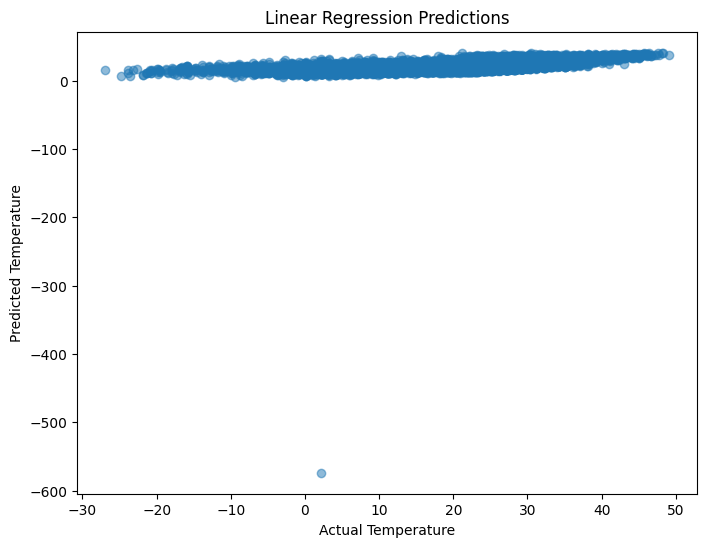

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.5
)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")

plt.title("Linear Regression Predictions")

plt.show()

## Linear Regression Results

- Linear Regression provided a simple baseline forecasting approach for temperature prediction.
- The model demonstrated moderate predictive capability but struggled with extreme values and nonlinear weather relationships.
- Several unrealistic prediction outliers were observed, indicating sensitivity to unusual environmental feature combinations.
- The results suggest that more advanced non-linear models are better suited for complex weather forecasting tasks.

## Random Forest Regressor

Random Forest was implemented as a non-linear ensemble learning method to improve forecasting accuracy and robustness compared to Linear Regression.

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [10]:
y_pred_rf = rf_model.predict(X_test)

In [11]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 3.0547783702473246
Random Forest RMSE: 4.603179505281514
Random Forest R²: 0.7756367418634864


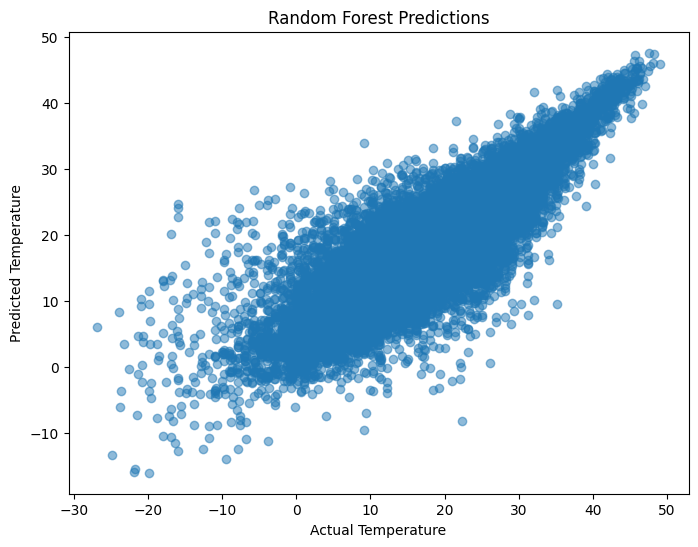

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")

plt.title("Random Forest Predictions")

plt.show()

## Random Forest Results

- Random Forest significantly improved prediction robustness compared to Linear Regression.
- MAE and RMSE values decreased substantially, indicating more accurate predictions overall.
- The model handled extreme prediction outliers more effectively than Linear Regression.
- Random Forest demonstrated stronger stability when modeling complex and non-linear weather relationships.

## Ensemble Forecasting Model

An ensemble prediction approach was implemented by combining Linear Regression and Random Forest predictions to improve forecasting stability.

In [13]:
ensemble_pred = (
    y_pred_linear + y_pred_rf
) / 2

In [14]:
ensemble_mae = mean_absolute_error(
    y_test,
    ensemble_pred
)

ensemble_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ensemble_pred
    )
)

ensemble_r2 = r2_score(
    y_test,
    ensemble_pred
)

print("Ensemble MAE:", ensemble_mae)
print("Ensemble RMSE:", ensemble_rmse)
print("Ensemble R²:", ensemble_r2)

Ensemble MAE: 4.281884178707217
Ensemble RMSE: 5.850905153832013
Ensemble R²: 0.6375216833957692


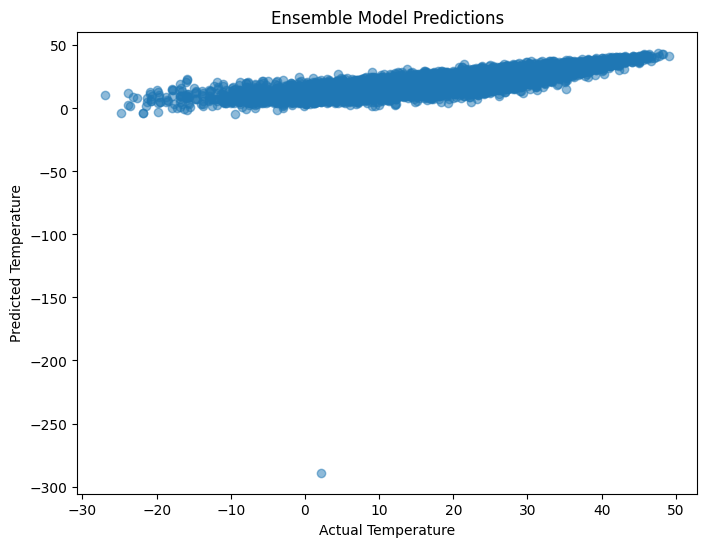

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    ensemble_pred,
    alpha=0.5
)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")

plt.title("Ensemble Model Predictions")

plt.show()

## Ensemble Model Results

- The ensemble model combined predictions from Linear Regression and Random Forest models.
- Ensemble averaging improved prediction stability compared to Linear Regression alone.
- However, Random Forest independently achieved stronger overall forecasting performance.
- The results demonstrate that ensemble methods may improve robustness, but do not always outperform the strongest individual model.

## Model Performance Comparison

The table below summarizes forecasting performance across all implemented models.

In [16]:
model_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Ensemble Model'
    ],
    'MAE': [
        mae,
        rf_mae,
        ensemble_mae
    ],
    'RMSE': [
        rmse,
        rf_rmse,
        ensemble_rmse
    ],
    'R² Score': [
        r2,
        rf_r2,
        ensemble_r2
    ]
})

model_results

,Model,MAE,RMSE,R² Score
0,Linear Regression,6.081105,8.385996,0.255362
1,Random Forest,3.054778,4.603180,0.775637
2,Ensemble Model,4.281884,5.850905,0.637522


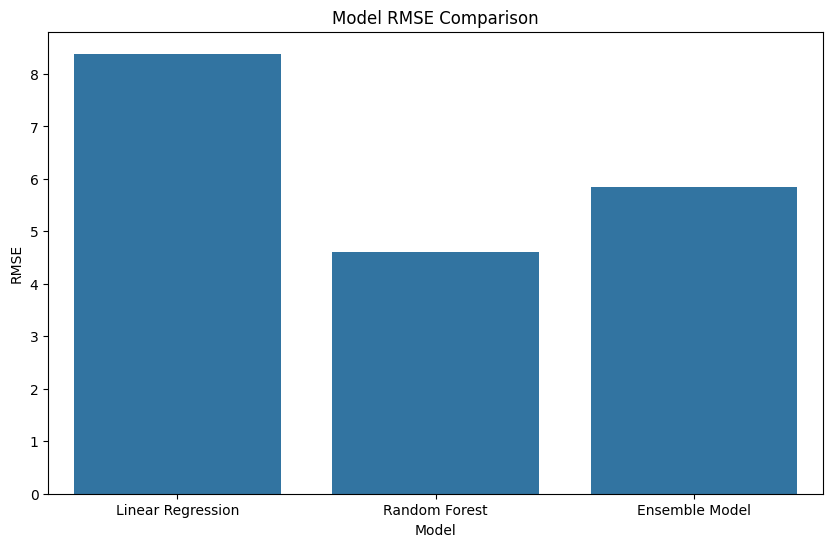

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='RMSE',
    data=model_results
)

plt.title('Model RMSE Comparison')

plt.ylabel('RMSE')

plt.show()

# Final Conclusions

- Comprehensive exploratory data analysis revealed strong geographical, environmental, and climate-related weather patterns.
- Temperature forecasting performance varied significantly across different machine learning models.
- Linear Regression provided a useful baseline but struggled with nonlinear relationships and extreme values.
- Random Forest achieved the strongest overall forecasting performance with lower prediction errors and improved robustness.
- Ensemble averaging improved stability compared to Linear Regression, though Random Forest remained the best-performing model overall.
- Environmental variables such as air quality indicators, humidity, and UV index demonstrated meaningful relationships with temperature behavior.